# **Computational Urban Comfort Indexing and Annealed Optimisation for Latent Potentials**

**Authors:** Sijie Yang, Zdravko Trivic, Yihan Zhu, Mahmoud Abdelrahman, Filip Biljecki*

by Urban Analytics Lab, National University of Singapore

---

**Note:** Each .ipynb file can be run independently. This work is licensed under a [Creative Commons Attribution 4.0 International License](https://creativecommons.org/licenses/by/4.0/).


# Data: Social Activity Data

This notebook prepares social-media activity proxies used by subsequent UCI modelling stages.

This notebook exposes social activity data outputs for downstream modelling in-memory via `act_gdf`, and supports direct export to GeoPackage.

Primary handover fields:
- Index for the location: `id`
- Activity-count columns: `eating`, `nature`, `community`, `walking`, `sightseeing`
- Derived indicators: `prevalent_activity`, `total_activity`
- Coordinates: `longitude`, `latitude`
- Geometry: `geometry`

Data source used in this notebook:
- `data/data_social_activity.gpkg`


## 1. Social Activity Intensity

We use social-media posting counts at each location $\mathbf{u}$ as a proxy of observed social activity intensity.

$$
\text{Activity Category Set } i = \{\textit{eating}, \textit{nature}, \textit{community}, \textit{walking}, \textit{sightseeing}\}
$$

$$
\text{SocialActivityIntensity}_{i,\mathbf{u}} = \text{PostNum}_{i,\mathbf{u}}
$$

Activity category definitions:
- `eating`: Eating and Drinking
- `nature`: Nature Exploration
- `community`: Community Gathering
- `walking`: Walking and Exercising
- `sightseeing`: Urban Sightseeing

This representation captures activity-specific participation patterns while preserving per-location comparability across categories.


In [1]:
import geopandas as gpd

# act_gdf: read social media intensity data as proxy for social activity
file_path = "./data/data_social_activity.gpkg"
act_gdf = gpd.read_file(file_path)

# This sets the coordinate reference system (CRS) of the 'act_gdf' GeoDataFrame to WGS 84 (EPSG:4326), 
# which is the standard geographic CRS using latitude and longitude.
act_gdf.crs = "EPSG:4326"

act_columns = ['eating', 'nature', 'community', 'walking', 'sightseeing']

print(act_gdf.crs)
print(act_gdf.columns)

# Calculate total number of activity posts across all categories for all locations
print(f"Total number of valid activity posts across all locations: {act_gdf[act_columns].sum().sum()}")

EPSG:4326
Index(['id', 'longitude', 'latitude', 'eating', 'nature', 'community',
       'walking', 'sightseeing', 'geometry'],
      dtype='object')
Total number of valid activity posts across all locations: 33250


## 2. Prevalent Activity and Total Activity Intensity


For each location $\mathbf{u}$, we identify the most prevalent activity category (highest post count):

$$
\text{PrevalentActivity}_{\mathbf{u}} = \underset{i}{\mathrm{argmax}} \; \text{SocialActivityIntensity}_{i,\mathbf{u}}
$$

where $\text{SocialActivityIntensity}_{i,\mathbf{u}}$ is the number of posts for activity $i$ at location $\mathbf{u}$. If no activity posts exist (i.e., $\sum_i \text{SocialActivityIntensity}_{i,\mathbf{u}} = 0$), we assign $\text{PrevalentActivity}_{\mathbf{u}} = \text{none}$.

We also compute total activity intensity across all categories:

$$
\text{TotalActivityIntensity}_{\mathbf{u}} = \sum_{i} \text{SocialActivityIntensity}_{i,\mathbf{u}}
$$

These two indicators summarize dominant activity type and aggregate activity load at each location.


In [99]:
# Calculate which activity is the most prevalent (i.e., has the highest count) for each location.
act_gdf['prevalent_activity'] = act_gdf[act_columns].idxmax(axis=1)
act_gdf.loc[act_gdf[act_columns].sum(axis=1) == 0, 'prevalent_activity'] = 'none'
# Calculate the total number of activity posts across all categories for each location.
act_gdf['total_activity'] = act_gdf[act_columns].sum(axis=1)

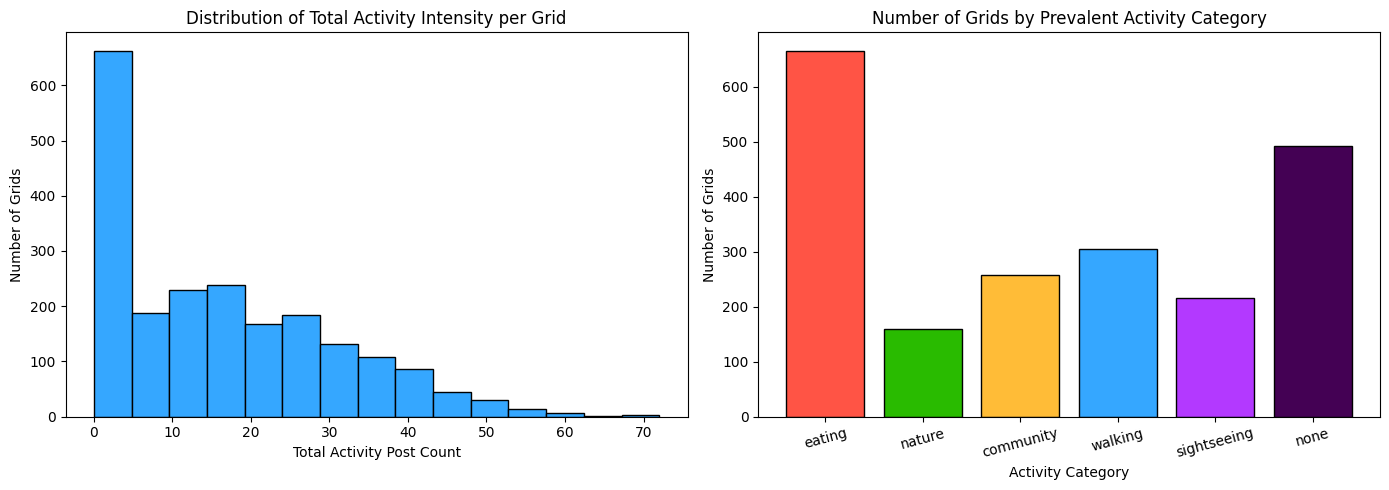

In [100]:
import matplotlib.pyplot as plt

# Plot two-related charts: (1) Total Activity (all grids) distribution histogram, (2) Bar: Number of Grids by Prevalent Social Activity Category
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar 1 (now first figure): Histogram of total activity count distribution
axes[0].hist(act_gdf['total_activity'], bins=15, color="#35A7FF", edgecolor="black")
axes[0].set_title('Distribution of Total Activity Intensity per Grid')
axes[0].set_xlabel('Total Activity Post Count')
axes[0].set_ylabel('Number of Grids')

# Bar 2 (move original bar to here): Number of Grids by Prevalent Social Activity Category
prevalent_counts = act_gdf['prevalent_activity'].value_counts().reindex(act_columns + ['none']).fillna(0)
axes[1].bar(prevalent_counts.index, prevalent_counts.values, color=[
    '#FF5445', '#29BB00', '#FFBC37', '#35A7FF', '#B339FF', '#440154'
], edgecolor="black")
axes[1].set_title('Number of Grids by Prevalent Activity Category')
axes[1].set_ylabel('Number of Grids')
axes[1].set_xlabel('Activity Category')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

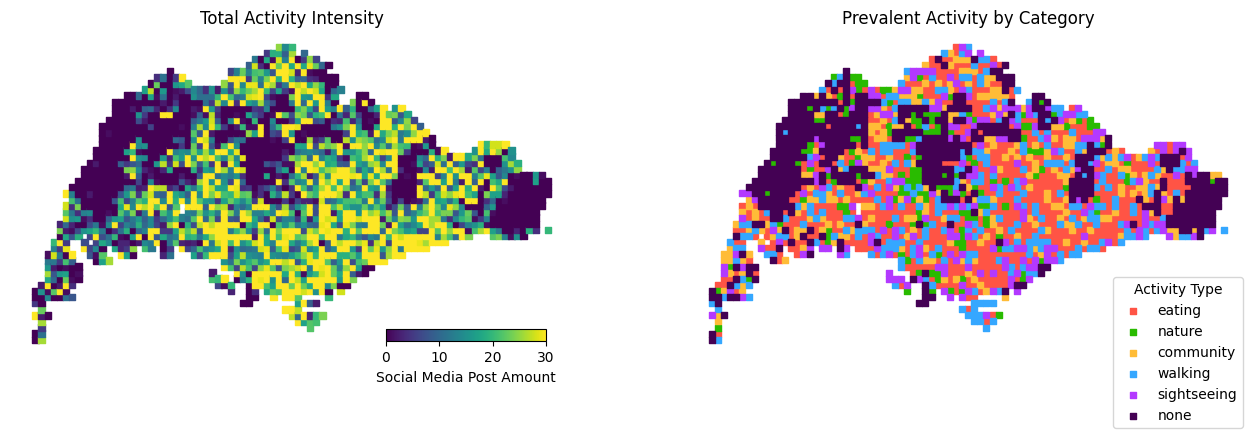

In [101]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))  # one row, two plots

# First plot: show the distribution of total_activity
act_gdf.plot(ax=axes[0], vmin=0, vmax=30, column='total_activity', marker='s', markersize=22)
axes[0].set_title('Total Activity Intensity')
axes[0].axis('off')

# Create a ScalarMappable with the colormap and value range used in the plot
norm = mpl.colors.Normalize(vmin=0, vmax=30)
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)  # Use the same colormap as in the plot
sm.set_array([])  # ScalarMappable is only for the colorbar

# Add a colorbar to the figure
# Adjust layout to make room for the colorbar at the bottom
cbar_ax = fig.add_axes([0.36, 0.31, 0.1, 0.015])  # [left, bottom, width, height]

# Create the colorbar with horizontal orientation
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Social Media Post Amount')  # Set colorbar label

# Second plot: display each location colored by most prevalent activity category
activity_colors = {
    'eating': '#FF5445',
    'nature': '#29BB00',
    'community': '#FFBC37',
    'walking': '#35A7FF',
    'sightseeing': '#B339FF',
    'none': '#440154'  # Used for locations with zero values
}

for activity, color in activity_colors.items():
    subset = act_gdf[act_gdf['prevalent_activity'] == activity]
    subset.plot(ax=axes[1], color=color, marker='s', markersize=22, label=activity)

axes[1].set_title('Prevalent Activity by Category')
axes[1].axis('off')
# Move the legend down (below the plot)
axes[1].legend(title="Activity Type", loc='lower right', bbox_to_anchor=(1, -0.25), ncol=1)

plt.show()


## 3. Global and Local Moran's I Analytics

This section evaluates spatial autocorrelation of activity intensity using global Moran's $I$ and local indicators (LISA).


In [127]:
import numpy as np
from libpysal.weights import KNN
from libpysal.weights import lag_spatial
from esda.moran import Moran, Moran_Local

# Create a spatial weights matrix using KNN
coords = np.array([(p.x, p.y) for p in act_gdf.geometry])  # 点
w = KNN.from_array(coords, k=8)  
w.transform = "r"

# For each activity, calculate and print Global Moran's I
activity_list = ['eating', 'nature', 'community', 'walking', 'sightseeing']
for activity in activity_list:
    if activity in act_gdf.columns:
        x = act_gdf[activity]
        global_moran = Moran(x, w)
        print(f"Activity: {activity}")
        print(f"  Moran's I: {global_moran.I:.4f}")
        print(f"  Expected I: {global_moran.EI:.4f}")
        print(f"  Z-Score: {global_moran.z_norm:.4f}")
        print(f"  P-Value: {global_moran.p_norm:.4f}")
        print("-" * 36)
    else:
        print(f"Warning: activity column '{activity}' not found in act_gdf.")

# Global Moran's I calculations for total_activity (for further use in plotting)
x = act_gdf['total_activity']
y = x - np.mean(x)
w_x = lag_spatial(w, act_gdf['total_activity'])
global_moran = Moran(act_gdf['total_activity'], w)

# Local Moran's I calculation
local_moran = Moran_Local(act_gdf['total_activity'], w)
act_gdf['lisa_quadrant'] = local_moran.q
color_map = {1: 'red', 2: 'lightblue', 3: 'blue', 4: 'pink', 0: 'grey'}
act_gdf['color'] = act_gdf['lisa_quadrant'].map(color_map)

Activity: eating
  Moran's I: 0.2700
  Expected I: -0.0005
  Z-Score: 25.0624
  P-Value: 0.0000
------------------------------------
Activity: nature
  Moran's I: 0.1407
  Expected I: -0.0005
  Z-Score: 13.0846
  P-Value: 0.0000
------------------------------------
Activity: community
  Moran's I: 0.2280
  Expected I: -0.0005
  Z-Score: 21.1714
  P-Value: 0.0000
------------------------------------
Activity: walking
  Moran's I: 0.1802
  Expected I: -0.0005
  Z-Score: 16.7416
  P-Value: 0.0000
------------------------------------
Activity: sightseeing
  Moran's I: 0.2036
  Expected I: -0.0005
  Z-Score: 18.9072
  P-Value: 0.0000
------------------------------------


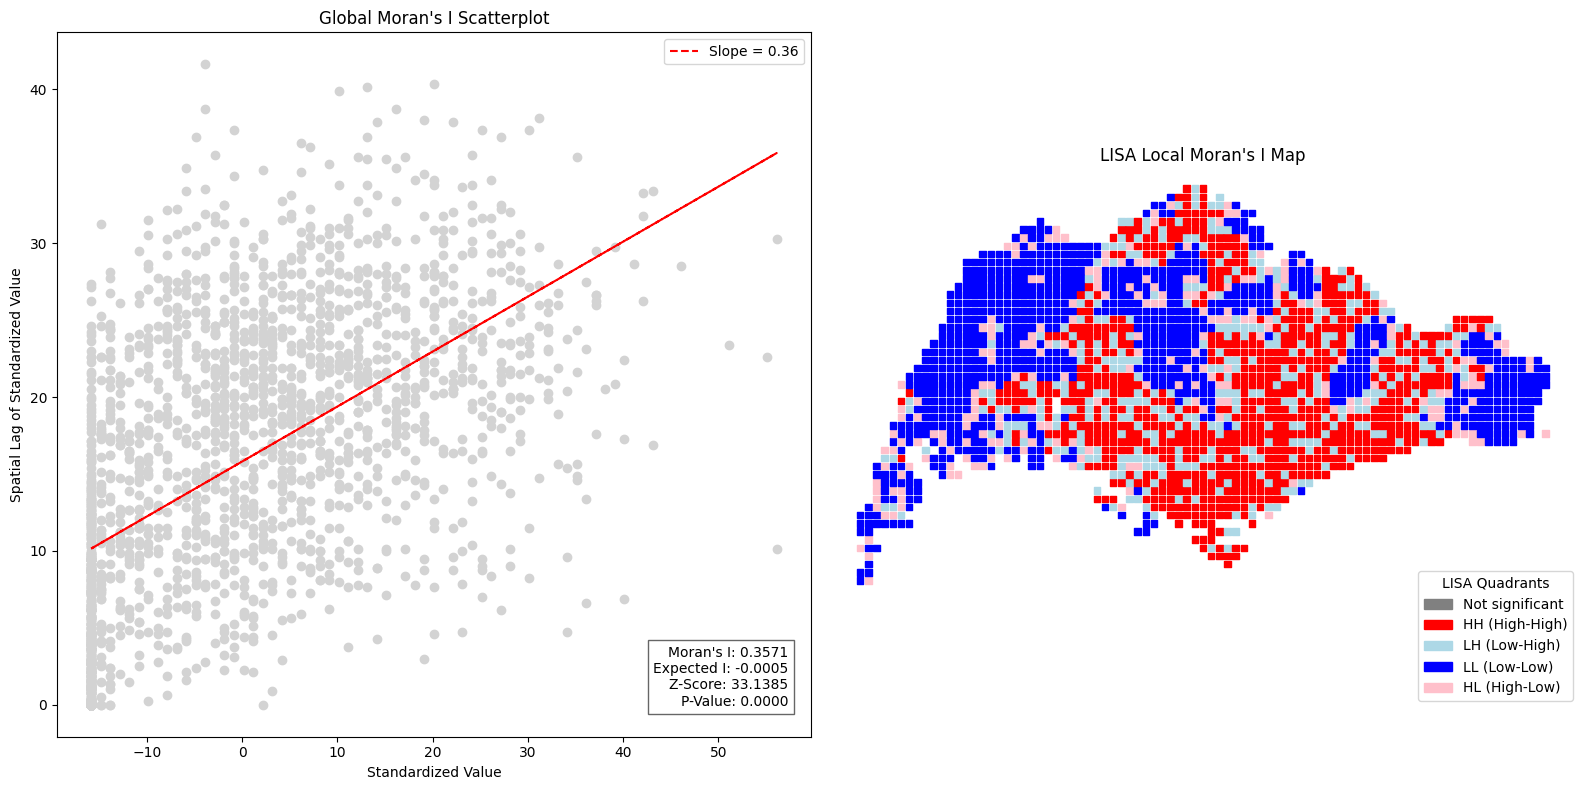

In [125]:
# Plot two related charts in one row: (1) Global Moran's I scatterplot, (2) LISA map
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# (1) Global Moran's I scatterplot
axes[0].scatter(y, w_x, color='lightgrey')
b, a = np.polyfit(y, w_x, 1)
axes[0].plot(y, a + b*y, 'r--', label=f'Slope = {b:.2f}')
axes[0].text(
    0.97, 0.04,
    f"Moran's I: {global_moran.I:.4f}\n"
    f"Expected I: {global_moran.EI:.4f}\n"
    f"Z-Score: {global_moran.z_norm:.4f}\n"
    f"P-Value: {global_moran.p_norm:.4f}",
    transform=axes[0].transAxes,
    bbox=dict(facecolor='white', alpha=0.6),
    verticalalignment='bottom',
    horizontalalignment='right',
)
axes[0].set_xlabel('Standardized Value')
axes[0].set_ylabel('Spatial Lag of Standardized Value')
axes[0].set_title("Global Moran's I Scatterplot")
axes[0].legend()

# (2) LISA Local Moran map
# To get a proper legend, we need to manually create legend handles
color_map = {1: 'red', 2: 'lightblue', 3: 'blue', 4: 'pink', 0: 'grey'}
lisa_labels = {
    1: "HH (High-High)", 
    2: "LH (Low-High)", 
    3: "LL (Low-Low)", 
    4: "HL (High-Low)", 
    0: "Not significant"
}
# Sort for legend order
handles = [mpatches.Patch(color=color_map[k], label=lisa_labels[k]) for k in sorted(color_map)]

act_gdf.plot(
    color=act_gdf['color'],
    ax=axes[1],
    marker='s', 
    markersize=22,
    legend=False
)
axes[1].legend(handles=handles, title="LISA Quadrants", loc='lower right', bbox_to_anchor=(1, -0.25))
axes[1].set_title("LISA Local Moran's I Map")
axes[1].axis('off')

plt.tight_layout()
plt.show()